# Principal Component Analysis of NLA Shape Surfaces

This notebook builds a linear compression baseline for the nonlinear-alignment shape dataset generated in `SAMPLE.ipynb`. Each positive surface is represented by

$$Y(k,z)=\log_{10}\mathcal A_\Theta(k,z),$$

sampled on a $31\times101$ redshift--wavenumber grid. We flatten each surface to 3131 features and compress it to at most 25 PCA coefficients. This cutoff is chosen because the variance spectrum and reconstruction error show strongly diminishing returns beyond roughly 20 modes. PCA is fit using the stored training split only; validation and test rows remain independent of the fit.

## PCA as a Linear Change of Coordinates

For surface $i$, define the flattened vector $\mathbf x_i=\operatorname{vec}[Y_i(z,k)]\in\mathbb R^{3131}$ and the training mean $\boldsymbol\mu$. PCA diagonalizes the training covariance,

$$C=\frac{1}{N_{\rm train}-1}X_c^{\mathsf T}X_c,\qquad C\mathbf v_j=\lambda_j\mathbf v_j,$$

where $X_c$ contains the centered rows $\mathbf x_i-\boldsymbol\mu$. The PCA coefficient of mode $j$ is

$$a_{ij}=(\mathbf x_i-\boldsymbol\mu)^{\mathsf T}\mathbf v_j,$$

and the rank-$m$ reconstruction is

$$\widehat{\mathbf x}_i^{(m)}=\boldsymbol\mu+\sum_{j=1}^{m}a_{ij}\mathbf v_j.$$

A complete set of 3131 orthonormal modes would be invertible up to floating-point error but would not compress the data. Here we deliberately retain only the leading 25 modes, so $\mathbf x_i\in\mathbb R^{3131}$ is mapped to a genuinely compressed latent vector $\mathbf a_i\in\mathbb R^{25}$. Reconstructions are therefore approximate. The individual and cumulative explained-variance fractions are

$$f_j=\frac{\lambda_j}{\sum_\ell\lambda_\ell},\qquad F_m=\sum_{j=1}^{m}f_j.$$

PCA makes the retained training coefficients uncorrelated, not necessarily independent or Gaussian. A linear projection also does not preserve the one-dimensional marginal distributions of the original grid features.

In [1]:
import json
import time
from pathlib import Path

import h5py
import joblib
import numpy
import sklearn
from matplotlib import colors, pyplot
from scipy import stats
from sklearn.decomposition import PCA

pyplot.rcParams.update({
    "font.family": "Times New Roman",
    "font.size": 18,
    "text.usetex": True,
})

print("NumPy:       ", numpy.__version__)
print("h5py:        ", h5py.__version__)
print("scikit-learn:", sklearn.__version__)

NumPy:        2.3.5
h5py:         3.15.1
scikit-learn: 1.7.2


In [2]:
base_path = Path.cwd().parent if Path.cwd().name == "Code" else Path.cwd()
dataset_file = base_path / "Data" / "SAMPLE" / "nla_shape_final_prior.hdf5"
pca_data_path = base_path / "Data" / "PCA"
figure_path = base_path / "Figure" / "PCA"
pca_data_path.mkdir(parents=True, exist_ok=True)
figure_path.mkdir(parents=True, exist_ok=True)

assert dataset_file.exists(), f"Missing generated sample file: {dataset_file}"
print("Project directory:", base_path)
print("Input dataset:    ", dataset_file)
print("PCA products:     ", pca_data_path)
print("PCA figures:      ", figure_path)

Project directory: /Users/s2227120/IAFlowCloud
Input dataset:     /Users/s2227120/IAFlowCloud/Data/SAMPLE/nla_shape_final_prior.hdf5
PCA products:      /Users/s2227120/IAFlowCloud/Data/PCA
PCA figures:       /Users/s2227120/IAFlowCloud/Figure/PCA


## Data Contract and Split Discipline

The authoritative compression target is `log10(components/A_theta)`. PCA is fit only on the 80,000 stored training rows. Explained variance and the PCA basis therefore contain no information from validation or test rows. The held-out test split is used below only to diagnose coefficient distributions; validation rows are used for rank-truncated reconstruction checks.

In [3]:
target_dataset = "components/A_theta"
number_of_pca_components = 25
number_of_display_components = 10
variance_thresholds = (0.95, 0.99, 0.999)
saturation_ranks = (10, 15, 20, 25)
reconstruction_check_size = 64
save_fitted_model = True

with h5py.File(dataset_file, "r") as dataset:
    z = dataset["coordinates/z"][:]
    k = dataset["coordinates/k"][:]
    target_shape = dataset[target_dataset].shape
    target_dtype = dataset[target_dataset].dtype
    target_chunks = dataset[target_dataset].chunks
    split_indices = {
        name: dataset[f"splits/{name}"][:]
        for name in ("train", "validation", "test")
    }
    stored_metadata = json.loads(dataset.attrs["metadata"])
    schema_version = dataset.attrs["schema_version"]
    generation_complete = bool(dataset.attrs["generation_complete"])

number_of_models, number_of_redshifts, number_of_wavenumbers = target_shape
number_of_features = number_of_redshifts * number_of_wavenumbers

assert schema_version == "4.0"
assert generation_complete
assert stored_metadata["recommended_primary_compression_target"] == "log10(A_theta)"
assert target_shape == (100000, 31, 101)
assert number_of_features == 3131
assert len(split_indices["train"]) == 80000
assert len(split_indices["validation"]) == 10000
assert len(split_indices["test"]) == 10000
for name, indices in split_indices.items():
    assert numpy.all(indices[1:] > indices[:-1]), f"{name} indices are not strictly increasing"
assert numpy.intersect1d(split_indices["train"], split_indices["validation"]).size == 0
assert numpy.intersect1d(split_indices["train"], split_indices["test"]).size == 0
assert numpy.intersect1d(split_indices["validation"], split_indices["test"]).size == 0
assert sum(len(indices) for indices in split_indices.values()) == number_of_models

print("Schema version:      ", schema_version)
print("Stored target:       ", target_dataset, target_shape, target_dtype)
print("HDF5 chunk shape:    ", target_chunks)
print("Flattened features:  ", number_of_features)
print("Coordinate ranges:   ", f"z={z[0]:.1f}--{z[-1]:.1f}, k={k[0]:.2g}--{k[-1]:.2g} Mpc^-1")
print("Split sizes:         ", {name: len(indices) for name, indices in split_indices.items()})

Schema version:       4.0
Stored target:        components/A_theta (100000, 31, 101) float32
HDF5 chunk shape:     (3125, 2, 7)
Flattened features:   3131
Coordinate ranges:    z=0.0--3.0, k=0.01--10 Mpc^-1
Split sizes:          {'train': 80000, 'validation': 10000, 'test': 10000}


## Flattening Convention

Each surface is flattened separately,

```text
(N, 31, 101) -> (N, 3131),
```

using NumPy's default C order. Thus feature $p=i_zN_k+i_k$. The same convention reshapes every PCA eigenvector back to `(31, 101)` for plotting. Flattening itself loses no information.

In [4]:
def flatten_surfaces(surfaces):
    values = numpy.asarray(surfaces)
    if values.ndim == 2:
        values = values[numpy.newaxis, ...]
    if values.ndim != 3 or values.shape[1:] != (number_of_redshifts, number_of_wavenumbers):
        raise ValueError(
            f"Expected (..., {number_of_redshifts}, {number_of_wavenumbers}); got {values.shape}"
        )
    return values.reshape(values.shape[0], number_of_features)


def reshape_features(features):
    values = numpy.asarray(features)
    if values.shape[-1] != number_of_features:
        raise ValueError(f"Expected final dimension {number_of_features}; got {values.shape}")
    return values.reshape(*values.shape[:-1], number_of_redshifts, number_of_wavenumbers)


with h5py.File(dataset_file, "r") as dataset:
    example_surface = numpy.log10(dataset[target_dataset][0].astype(numpy.float32))
example_flat = flatten_surfaces(example_surface)[0]
example_restored = reshape_features(example_flat)
assert numpy.array_equal(example_surface, example_restored)
print("Verified exact reshape round trip:", example_surface.shape, "->", example_flat.shape, "->", example_restored.shape)

Verified exact reshape round trip: (31, 101) -> (3131,) -> (31, 101)


## Memory-Conscious HDF5 Loading

The flattened training matrix contains about one billion bytes at `float32`. The loader below preallocates that matrix and reads the compressed HDF5 target in contiguous blocks aligned with its sample-axis chunking. It then retains only rows belonging to the requested split. This reads the target once and avoids expensive scattered access across the 1.5 GiB file. Positivity and finiteness are checked before applying the logarithm.

In [5]:
def load_log10_flattened(dataset_path, dataset_name, indices, dtype=numpy.float32):
    indices = numpy.asarray(indices, dtype=numpy.int64)
    if indices.ndim != 1 or (indices.size > 1 and not numpy.all(indices[1:] > indices[:-1])):
        raise ValueError("indices must be a one-dimensional, strictly increasing array")

    with h5py.File(dataset_path, "r") as dataset:
        source = dataset[dataset_name]
        if source.shape[1:] != (number_of_redshifts, number_of_wavenumbers):
            raise ValueError(f"Unexpected source shape: {source.shape}")
        if indices.size and (indices[0] < 0 or indices[-1] >= source.shape[0]):
            raise IndexError("split indices lie outside the source dataset")

        row_mask = numpy.zeros(source.shape[0], dtype=bool)
        row_mask[indices] = True
        flattened = numpy.empty((indices.size, number_of_features), dtype=dtype)
        block_size = source.chunks[0] if source.chunks is not None else 2048
        write_start = 0

        for read_start in range(0, source.shape[0], block_size):
            read_stop = min(read_start + block_size, source.shape[0])
            local_mask = row_mask[read_start:read_stop]
            if not local_mask.any():
                continue

            block = numpy.asarray(source[read_start:read_stop], dtype=dtype)
            selected = block[local_mask]
            if not numpy.isfinite(selected).all() or not numpy.all(selected > 0):
                raise ValueError(f"Non-finite or non-positive values in rows {read_start}:{read_stop}")
            numpy.log10(selected, out=selected)
            write_stop = write_start + selected.shape[0]
            flattened[write_start:write_stop] = selected.reshape(selected.shape[0], number_of_features)
            write_start = write_stop
            print(f"\rLoaded {write_start:,}/{indices.size:,} selected rows", end="")

    print()
    assert write_start == indices.size
    assert numpy.isfinite(flattened).all()
    return flattened


def load_log10_rows(dataset_path, dataset_name, indices, dtype=numpy.float32):
    indices = numpy.asarray(indices, dtype=numpy.int64)
    if indices.ndim != 1 or (indices.size > 1 and not numpy.all(indices[1:] > indices[:-1])):
        raise ValueError("indices must be a one-dimensional, strictly increasing array")
    with h5py.File(dataset_path, "r") as dataset:
        values = numpy.asarray(dataset[dataset_name][indices], dtype=dtype)
    if not numpy.isfinite(values).all() or not numpy.all(values > 0):
        raise ValueError("Selected values are non-finite or non-positive")
    numpy.log10(values, out=values)
    return values.reshape(values.shape[0], number_of_features)

In [6]:
estimated_training_gib = (
    len(split_indices["train"]) * number_of_features * numpy.dtype(numpy.float32).itemsize / 1024**3
)
print(f"Expected training-matrix allocation: {estimated_training_gib:.2f} GiB")
loading_start = time.perf_counter()
training_matrix = load_log10_flattened(
    dataset_file,
    target_dataset,
    split_indices["train"],
)
loading_seconds = time.perf_counter() - loading_start
assert training_matrix.shape == (80000, 3131)
print("Training matrix:", training_matrix.shape, training_matrix.dtype)
print(f"Loading time:   {loading_seconds:.1f} s")

Expected training-matrix allocation: 0.93 GiB
Loaded 80,000/80,000 selected rows
Training matrix: (80000, 3131) float32
Loading time:   9.7 s


## Fit a 25-Component PCA Compressor

PCA mean-centers every grid feature internally. We deliberately do not divide individual grid cells by their standard deviations: all features already describe the same dimensionless log-amplitude, and per-cell standardization would change the scientific metric.

Only the leading 25 modes are retained. The deterministic covariance eigensolver is fast for 3131 features in this dataset and gives stable leading eigenvalues and variance fractions. Although it diagonalizes the complete feature covariance internally, the fitted model stores and transforms only the requested 25 modes. Whitening remains disabled, so coefficient variances retain their physical PCA meaning.

In [7]:
pca = PCA(
    n_components=number_of_pca_components,
    svd_solver="covariance_eigh",
    whiten=False,
)
fit_start = time.perf_counter()
pca.fit(training_matrix)
fit_seconds = time.perf_counter() - fit_start

assert pca.n_components_ == number_of_pca_components
assert pca.components_.shape == (number_of_pca_components, number_of_features)
assert pca.mean_.shape == (number_of_features,)
assert numpy.isfinite(pca.components_).all()
assert numpy.all(pca.explained_variance_ >= 0)
captured_variance = float(pca.explained_variance_ratio_.sum())
assert 0.9999 < captured_variance <= 1.0

orthogonality_error = numpy.max(
    numpy.abs(pca.components_ @ pca.components_.T - numpy.eye(number_of_pca_components))
)
assert orthogonality_error < 1e-4

model_file = pca_data_path / "pca_log10_A_theta_25_components.joblib"
if save_fitted_model:
    joblib.dump(pca, model_file, compress=3)
    print("Saved fitted PCA:", model_file)

print(f"Fit time:                    {fit_seconds:.1f} s")
print(f"Number of PCA components:    {pca.n_components_:,}")
print(f"Captured training variance:  {captured_variance:.10f}")
print(f"Orthogonality error:         {orthogonality_error:.3e}")

del training_matrix

Saved fitted PCA: /Users/s2227120/IAFlowCloud/Data/PCA/pca_log10_A_theta_25_components.joblib
Fit time:                    10.3 s
Number of PCA components:    25
Captured training variance:  0.9999863505
Orthogonality error:         8.345e-07


## Encode, Decode, and Evaluate 25-Component Reconstruction

The helpers below use exactly the first `rank` ordered eigenvectors, up to the fitted maximum of 25. The default encoding therefore maps each 3131-feature surface to 25 coefficients. Every available rank is a lossy compression, and its accuracy must be measured on held-out rows.

In [8]:
def encode_pca(flattened, fitted_pca, rank=None):
    values = numpy.asarray(flattened)
    one_surface = values.ndim == 1
    matrix = values[numpy.newaxis, :] if one_surface else values
    if matrix.ndim != 2 or matrix.shape[1] != fitted_pca.n_features_in_:
        raise ValueError(f"Expected (*, {fitted_pca.n_features_in_}); got {values.shape}")
    if rank is None:
        rank = fitted_pca.n_components_
    if not 1 <= rank <= fitted_pca.n_components_:
        raise ValueError(f"rank must lie in [1, {fitted_pca.n_components_}]")
    coefficients = (matrix - fitted_pca.mean_) @ fitted_pca.components_[:rank].T
    return coefficients[0] if one_surface else coefficients


def decode_pca(coefficients, fitted_pca):
    values = numpy.asarray(coefficients)
    one_surface = values.ndim == 1
    matrix = values[numpy.newaxis, :] if one_surface else values
    if matrix.ndim != 2 or not 1 <= matrix.shape[1] <= fitted_pca.n_components_:
        raise ValueError(f"Unexpected coefficient shape: {values.shape}")
    reconstructed = matrix @ fitted_pca.components_[:matrix.shape[1]] + fitted_pca.mean_
    return reconstructed[0] if one_surface else reconstructed


def reconstruction_metrics(original, reconstructed):
    residual = reconstructed.astype(numpy.float64) - original.astype(numpy.float64)
    relative_physical_error = numpy.abs(numpy.expm1(numpy.log(10.0) * residual))
    return {
        "log_rmse": float(numpy.sqrt(numpy.mean(residual**2))),
        "maximum_absolute_log_error": float(numpy.max(numpy.abs(residual))),
        "maximum_relative_A_theta_error": float(numpy.max(relative_physical_error)),
    }

In [9]:
maximum_rank_metrics = {}
for split_name in ("train", "validation", "test"):
    check_indices = split_indices[split_name][:reconstruction_check_size]
    original = load_log10_rows(dataset_file, target_dataset, check_indices)
    coefficients = encode_pca(original, pca, rank=number_of_pca_components)
    reconstructed = decode_pca(coefficients, pca)
    maximum_rank_metrics[split_name] = reconstruction_metrics(original, reconstructed)

print(f"{'Split':12s} {'log RMSE':>14s} {'max |log error|':>18s} {'max relative error':>20s}")
print("-" * 68)
for split_name, metrics in maximum_rank_metrics.items():
    print(
        f"{split_name:12s} {metrics['log_rmse']:14.4e} "
        f"{metrics['maximum_absolute_log_error']:18.4e} "
        f"{metrics['maximum_relative_A_theta_error']:20.4e}"
    )

assert all(numpy.isfinite(list(metrics.values())).all() for metrics in maximum_rank_metrics.values())
print("The 25-component compressor produced finite reconstructions for every stored split.")

Split              log RMSE    max |log error|   max relative error
--------------------------------------------------------------------
train            8.5916e-04         1.2080e-02           2.8205e-02
validation       8.4294e-04         1.6661e-02           3.9110e-02
test             9.6641e-04         2.2538e-02           5.0572e-02
The 25-component compressor produced finite reconstructions for every stored split.


## Individual and Cumulative Explained Variance

The individual spectrum shows how strongly each orthogonal mode varies across the training population. The cumulative curve determines the smallest latent dimension that retains a chosen fraction of total training variance. Variance retention is useful for choosing candidate ranks, but it is not by itself a guarantee of small pointwise or tail reconstruction errors.

 Variance retained   Components    Compression ratio
------------------------------------------------------
           95.000%            2             1565.50x
           99.000%            4              782.75x
           99.900%            9              347.89x

All 25 components retain 99.99862313% of training variance.


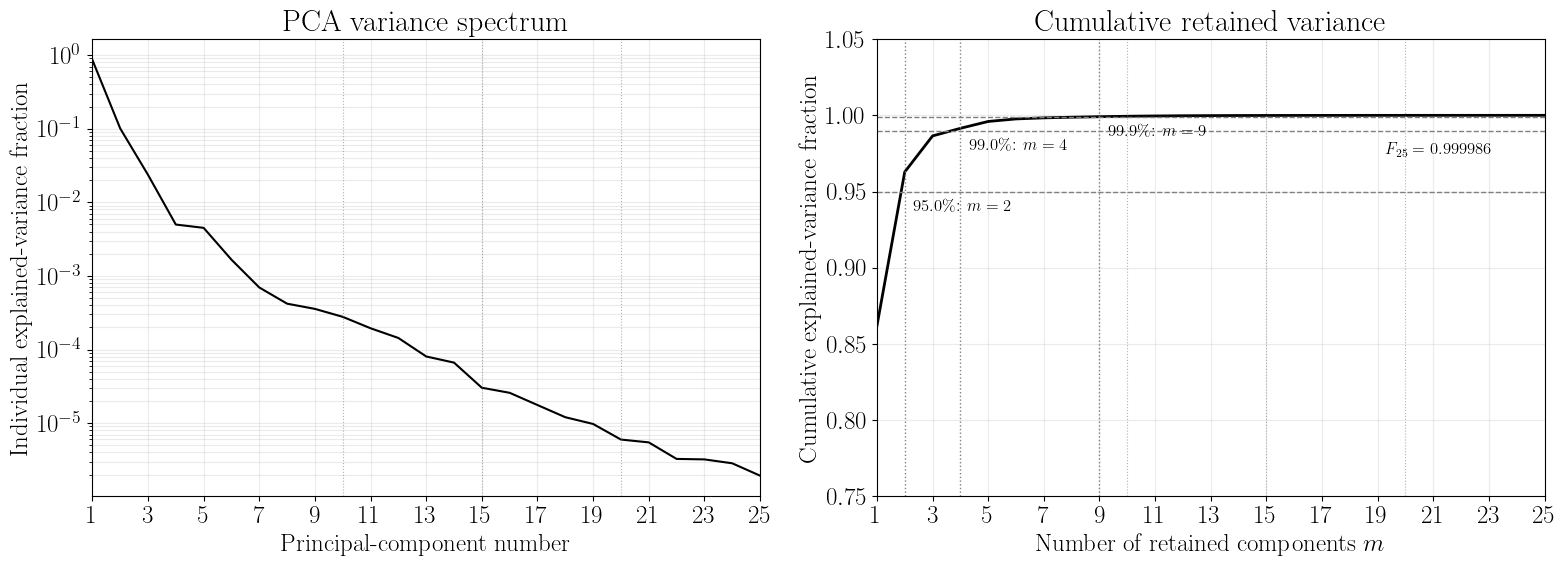

In [10]:
explained_fraction = pca.explained_variance_ratio_
cumulative_fraction = numpy.cumsum(explained_fraction)
component_number = numpy.arange(1, pca.n_components_ + 1)

variance_ranks = {}
for threshold in variance_thresholds:
    if threshold <= cumulative_fraction[-1] + 1e-12:
        rank = int(numpy.searchsorted(cumulative_fraction, threshold) + 1)
        variance_ranks[threshold] = rank

print(f"{'Variance retained':>18s} {'Components':>12s} {'Compression ratio':>20s}")
print("-" * 54)
for threshold, rank in variance_ranks.items():
    print(f"{threshold:18.3%} {rank:12d} {number_of_features / rank:19.2f}x")
print(f"\nAll {pca.n_components_} components retain {cumulative_fraction[-1]:.8%} of training variance.")

figure, plots = pyplot.subplots(1, 2, figsize=(16, 6))
positive_floor = numpy.finfo(explained_fraction.dtype).tiny
plots[0].plot(component_number, numpy.maximum(explained_fraction, positive_floor), color="black")
plots[0].set_yscale("log")
plots[0].set_xlim(1, number_of_pca_components)
plots[0].set_xticks(numpy.arange(1, number_of_pca_components + 1, 2))
plots[0].set_xlabel("Principal-component number")
plots[0].set_ylabel("Individual explained-variance fraction")
plots[0].set_title("PCA variance spectrum")
plots[0].grid(alpha=0.25, which="both")

plots[1].plot(component_number, cumulative_fraction, color="black", linewidth=2)
for rank in saturation_ranks:
    plots[0].axvline(rank, color="grey", linestyle=":", linewidth=0.8, alpha=0.6)
    plots[1].axvline(rank, color="grey", linestyle=":", linewidth=0.8, alpha=0.6)
for threshold, rank in variance_ranks.items():
    plots[1].axhline(threshold, color="grey", linestyle="--", linewidth=1)
    plots[1].axvline(rank, color="grey", linestyle=":", linewidth=1)
    plots[1].annotate(
        rf"${100 * threshold:.1f}\%$: $m={rank}$",
        xy=(rank, threshold),
        xytext=(6, -14),
        textcoords="offset points",
        fontsize=12,
    )
plots[1].annotate(
    rf"$F_{{25}}={cumulative_fraction[-1]:.6f}$",
    xy=(number_of_pca_components, cumulative_fraction[-1]),
    xytext=(-115, -28),
    textcoords="offset points",
    fontsize=12,
)
plots[1].set_xlim(1, number_of_pca_components)
plots[1].set_xticks(numpy.arange(1, number_of_pca_components + 1, 2))
plots[1].set_ylim(0.75, 1.05)
plots[1].set_xlabel("Number of retained components $m$")
plots[1].set_ylabel("Cumulative explained-variance fraction")
plots[1].set_title("Cumulative retained variance")
plots[1].grid(alpha=0.25, which="both")

figure.tight_layout()
figure.savefig(figure_path / "Explained_Variance.pdf", dpi=512, bbox_inches="tight")
pyplot.show()

## Reconstruction Error and Saturation by Rank

The fitted 25-mode basis can be truncated without refitting. We evaluate every rank from 1 through 25 on validation rows, then highlight the variance-selected ranks together with ranks 10, 15, 20, and 25. This makes the onset of diminishing reconstruction returns visible instead of inferring it from the variance spectrum alone. Errors are reported both in the compressed log target and after returning to the positive physical amplitude with $\mathcal A_\Theta=10^Y$.

  Rank     Variance      Ratio       log RMSE    max |log error|   max relative error
--------------------------------------------------------------------------------------
     2   96.283060%   1565.50x     5.2969e-02         3.8706e-01           9.7423e-01
     4   99.146783%    782.75x     2.4291e-02         1.7205e-01           4.8610e-01
     9   99.910498%    347.89x     8.0798e-03         1.0022e-01           2.5956e-01
    10   99.938309%    313.10x     6.7510e-03         8.8341e-02           2.2558e-01
    15   99.989831%    208.73x     2.6084e-03         3.9482e-02           8.6901e-02
    20   99.996948%    156.55x     1.3955e-03         3.4565e-02           8.2841e-02
    25   99.998623%    125.24x     8.7387e-04         2.3031e-02           5.4461e-02


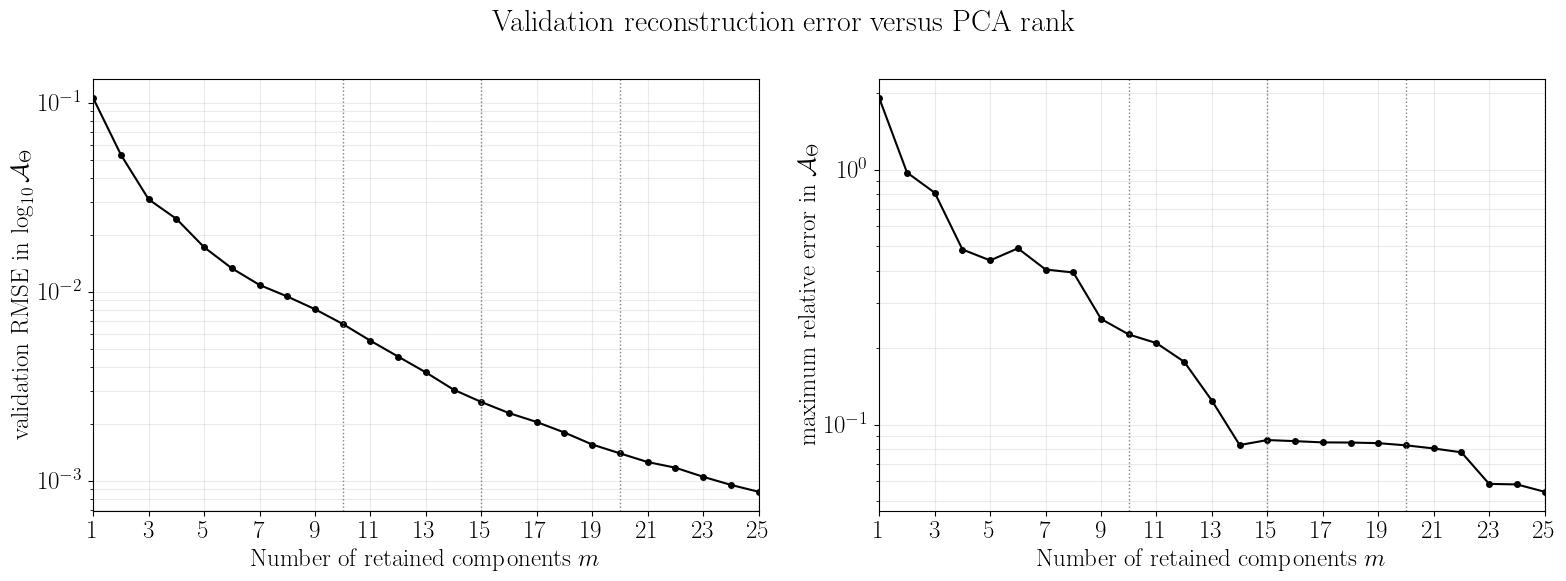

In [11]:
validation_check_indices = split_indices["validation"][:256]
validation_original = load_log10_rows(dataset_file, target_dataset, validation_check_indices)
validation_scores = encode_pca(validation_original, pca, rank=number_of_pca_components)
rank_metrics = {}

for rank in range(1, number_of_pca_components + 1):
    reconstructed = decode_pca(validation_scores[:, :rank], pca)
    rank_metrics[rank] = reconstruction_metrics(validation_original, reconstructed)

diagnostic_ranks = sorted(set(variance_ranks.values()) | set(saturation_ranks))

print(
    f"{'Rank':>6s} {'Variance':>12s} {'Ratio':>10s} {'log RMSE':>14s} "
    f"{'max |log error|':>18s} {'max relative error':>20s}"
)
print("-" * 86)
for rank in diagnostic_ranks:
    metrics = rank_metrics[rank]
    print(
        f"{rank:6d} {cumulative_fraction[rank - 1]:12.6%} {number_of_features / rank:9.2f}x "
        f"{metrics['log_rmse']:14.4e} {metrics['maximum_absolute_log_error']:18.4e} "
        f"{metrics['maximum_relative_A_theta_error']:20.4e}"
    )

rank_coordinate = numpy.arange(1, number_of_pca_components + 1)
log_rmse_by_rank = numpy.array([rank_metrics[rank]["log_rmse"] for rank in rank_coordinate])
maximum_relative_error_by_rank = numpy.array([
    rank_metrics[rank]["maximum_relative_A_theta_error"] for rank in rank_coordinate
])

figure, plots = pyplot.subplots(1, 2, figsize=(16, 6))
plots[0].plot(rank_coordinate, log_rmse_by_rank, color="black", marker="o", markersize=4)
plots[0].set_yscale("log")
plots[0].set_ylabel(r"validation RMSE in $\log_{10}\mathcal A_\Theta$")
plots[1].plot(rank_coordinate, maximum_relative_error_by_rank, color="black", marker="o", markersize=4)
plots[1].set_yscale("log")
plots[1].set_ylabel(r"maximum relative error in $\mathcal A_\Theta$")
for plot in plots:
    for rank in saturation_ranks:
        plot.axvline(rank, color="grey", linestyle=":", linewidth=1)
    plot.set_xlim(1, number_of_pca_components)
    plot.set_xticks(numpy.arange(1, number_of_pca_components + 1, 2))
    plot.set_xlabel("Number of retained components $m$")
    plot.grid(alpha=0.25, which="both")
figure.suptitle("Validation reconstruction error versus PCA rank")
figure.tight_layout()
figure.savefig(figure_path / "Reconstruction_Error_by_Rank.pdf", dpi=512, bbox_inches="tight")
pyplot.show()

## Shapes of the First Ten Principal Components

Each row of `pca.components_` is a unit-norm direction in flattened $\log_{10}\mathcal A_\Theta$ space. Reshaping restores its dependence on redshift and wavenumber. A component is a perturbation pattern, not a physical amplitude surface, and its overall sign is arbitrary. Every panel therefore uses a symmetric, independently normalized color scale to emphasize morphology; colors should not be compared as absolute amplitudes between panels.

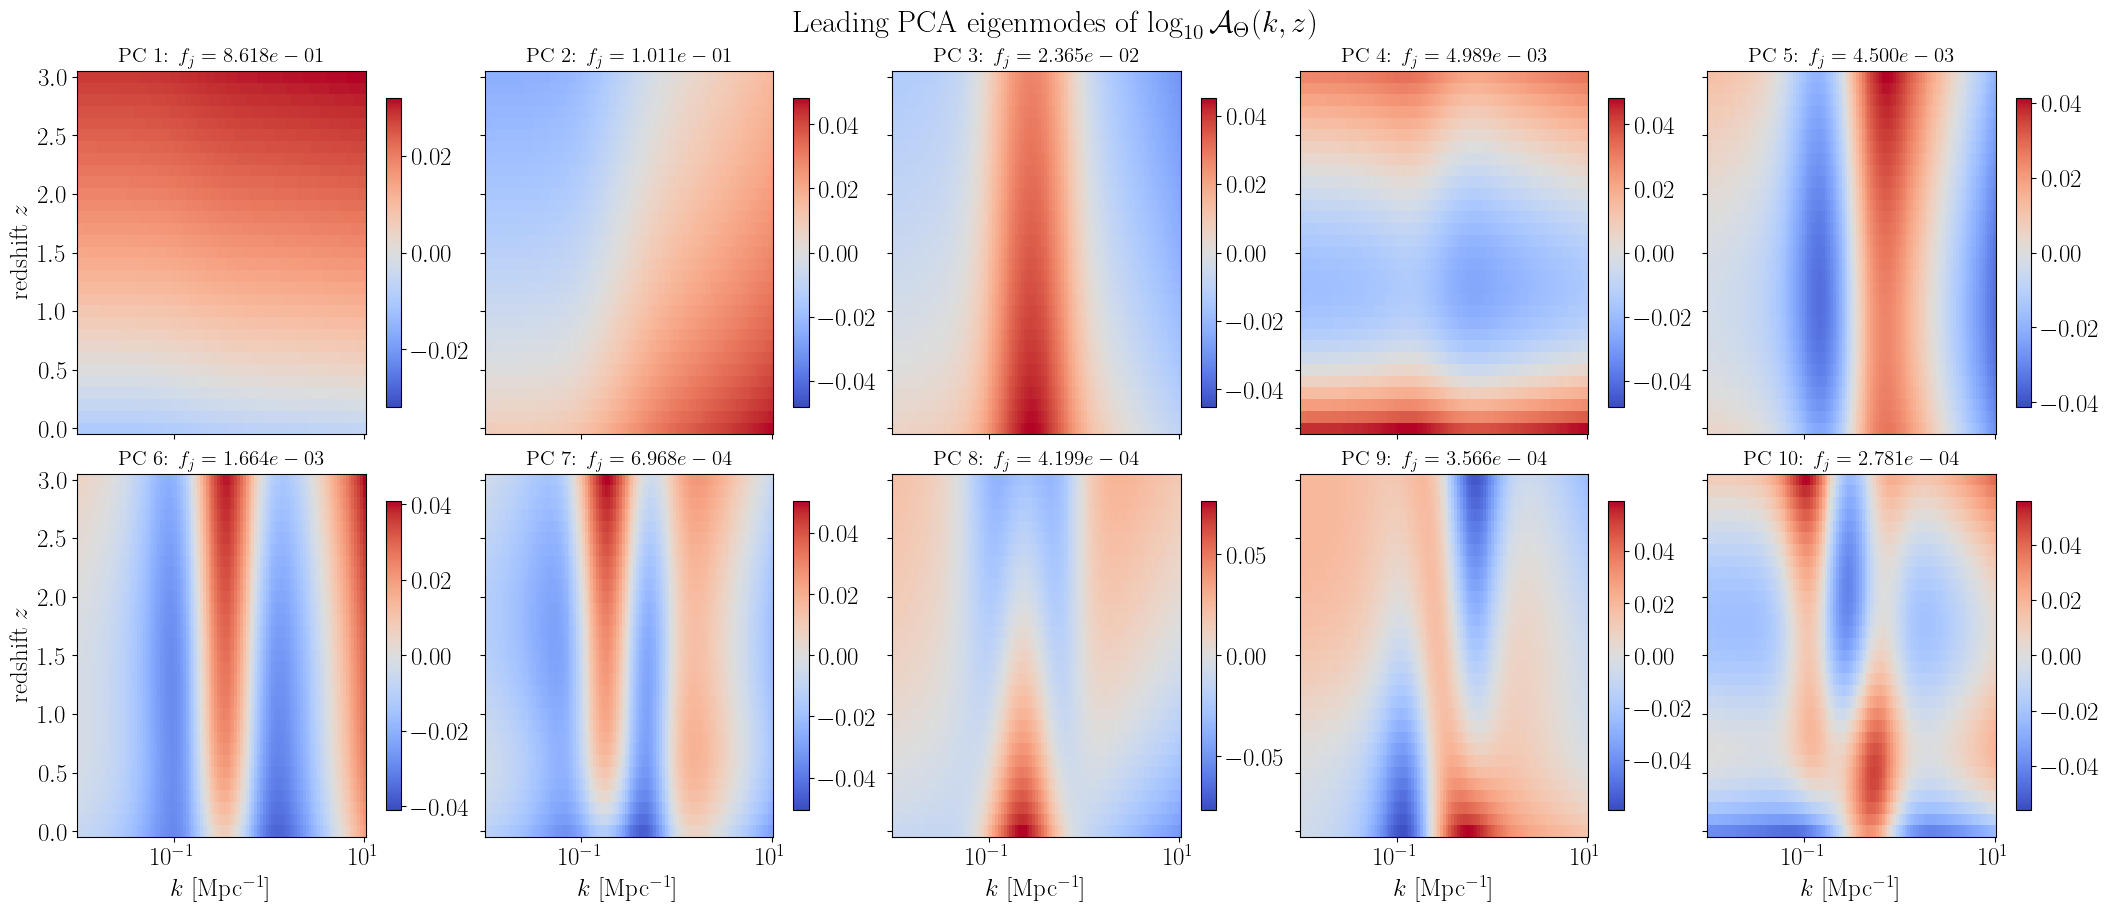

In [12]:
figure, plots = pyplot.subplots(
    2,
    5,
    figsize=(21, 9),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

for component_index, plot in enumerate(plots.flat[:number_of_display_components]):
    mode = reshape_features(pca.components_[component_index])
    colour_limit = float(numpy.max(numpy.abs(mode)))
    normalization = colors.TwoSlopeNorm(vmin=-colour_limit, vcenter=0.0, vmax=colour_limit)
    image = plot.pcolormesh(
        k,
        z,
        mode,
        shading="auto",
        cmap="coolwarm",
        norm=normalization,
    )
    plot.set_xscale("log")
    plot.set_title(
        rf"PC {component_index + 1}: $f_j={explained_fraction[component_index]:.3e}$",
        fontsize=15,
    )
    figure.colorbar(image, ax=plot, pad=0.02, shrink=0.85)

for plot in plots[-1]:
    plot.set_xlabel(r"$k$ [Mpc$^{-1}$]")
for plot in plots[:, 0]:
    plot.set_ylabel(r"redshift $z$")

figure.suptitle(r"Leading PCA eigenmodes of $\log_{10}\mathcal A_\Theta(k,z)$", fontsize=22)
figure.savefig(figure_path / "Principal_Components_First_10.pdf", dpi=512, bbox_inches="tight")
pyplot.show()

## Held-Out PCA Coefficient Distributions

A linear rotation does not preserve the marginal distribution of every coordinate. PCA guarantees zero training means and diagonal training covariance, but uncorrelated coefficients need not be statistically independent or Gaussian. Only a multivariate-Gaussian input is guaranteed to remain jointly Gaussian under the PCA rotation.

We project the independent test split onto the first ten modes. Coefficient $j$ is divided by $\sqrt{\lambda_j}$, using its training variance, so a standard normal provides a common reference. Skewness and excess kurtosis quantify asymmetry and tail shape. Formal normality-test $p$-values are deliberately omitted because 10,000 samples can make scientifically tiny deviations appear highly significant.

In [13]:
def project_log10_split_in_blocks(
    dataset_path, dataset_name, indices, mean, components, dtype=numpy.float32
):
    indices = numpy.asarray(indices, dtype=numpy.int64)
    if indices.ndim != 1 or (indices.size > 1 and not numpy.all(indices[1:] > indices[:-1])):
        raise ValueError("indices must be a one-dimensional, strictly increasing array")
    scores = numpy.empty((indices.size, components.shape[0]), dtype=dtype)

    with h5py.File(dataset_path, "r") as dataset:
        source = dataset[dataset_name]
        row_mask = numpy.zeros(source.shape[0], dtype=bool)
        row_mask[indices] = True
        block_size = source.chunks[0] if source.chunks is not None else 2048
        write_start = 0

        for read_start in range(0, source.shape[0], block_size):
            read_stop = min(read_start + block_size, source.shape[0])
            local_mask = row_mask[read_start:read_stop]
            if not local_mask.any():
                continue
            block = numpy.asarray(source[read_start:read_stop], dtype=dtype)
            selected = block[local_mask]
            if not numpy.isfinite(selected).all() or not numpy.all(selected > 0):
                raise ValueError(f"Non-finite or non-positive values in rows {read_start}:{read_stop}")
            numpy.log10(selected, out=selected)
            flattened = selected.reshape(selected.shape[0], number_of_features)
            write_stop = write_start + flattened.shape[0]
            scores[write_start:write_stop] = (flattened - mean) @ components.T
            write_start = write_stop
            print(f"\rProjected {write_start:,}/{indices.size:,} selected rows", end="")

    print()
    assert write_start == indices.size
    return scores


test_scores = project_log10_split_in_blocks(
    dataset_file,
    target_dataset,
    split_indices["test"],
    pca.mean_,
    pca.components_[:number_of_display_components],
)
leading_standard_deviations = numpy.sqrt(pca.explained_variance_[:number_of_display_components])
assert numpy.all(leading_standard_deviations > 0)
standardized_test_scores = test_scores / leading_standard_deviations
print("Held-out score matrix:", standardized_test_scores.shape)

Projected 10,000/10,000 selected rows
Held-out score matrix: (10000, 10)


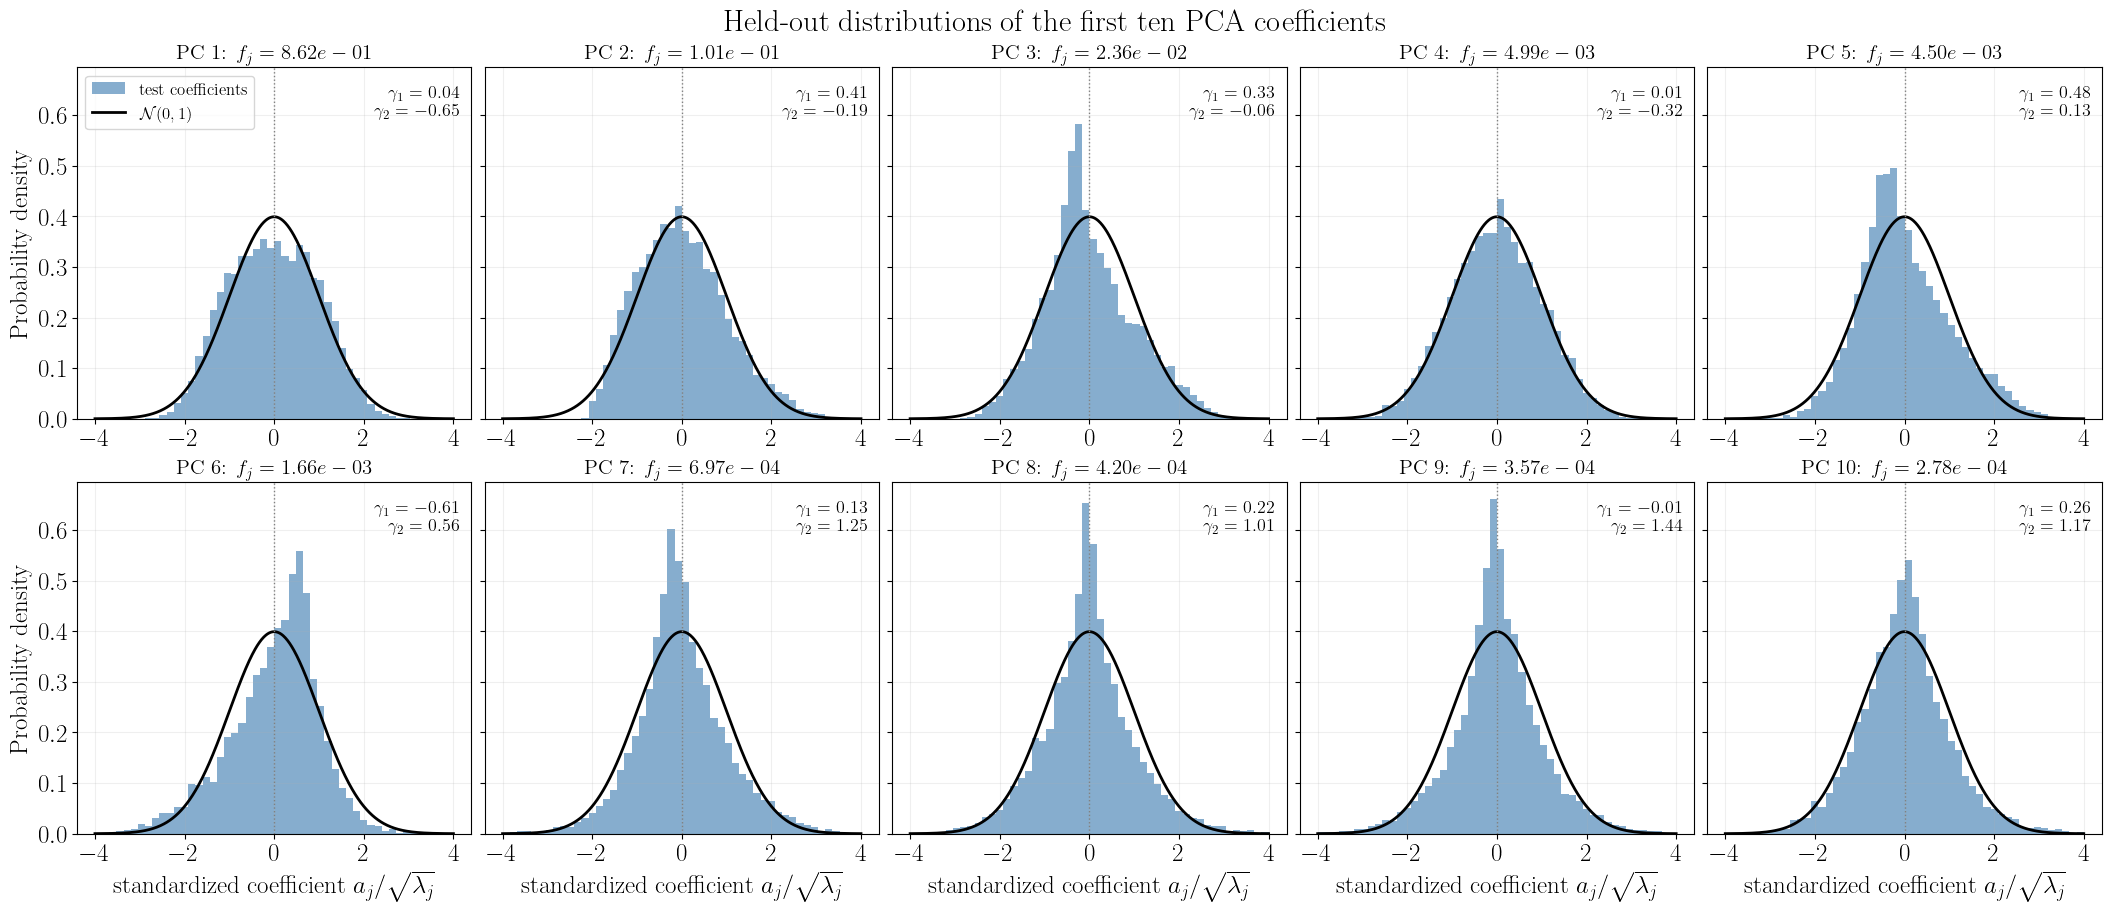

 PC       mean        std     skewness    excess kurtosis
----------------------------------------------------------
  1     -0.018      0.985        0.037             -0.647
  2      0.011      0.996        0.407             -0.192
  3     -0.006      0.997        0.334             -0.059
  4     -0.005      0.998        0.011             -0.320
  5      0.024      1.012        0.483              0.133
  6     -0.000      0.993       -0.609              0.564
  7     -0.006      0.998        0.126              1.246
  8     -0.016      1.005        0.221              1.015
  9     -0.001      0.998       -0.014              1.444
 10      0.004      1.003        0.257              1.165


In [14]:
figure, plots = pyplot.subplots(
    2,
    5,
    figsize=(21, 9),
    sharey=True,
    constrained_layout=True,
)
coefficient_diagnostics = []

for component_index, plot in enumerate(plots.flat[:number_of_display_components]):
    values = standardized_test_scores[:, component_index].astype(numpy.float64)
    skewness = float(stats.skew(values, bias=False))
    excess_kurtosis = float(stats.kurtosis(values, fisher=True, bias=False))
    display_limit = max(4.0, float(numpy.quantile(numpy.abs(values), 0.995)))
    outside_fraction = float(numpy.mean(numpy.abs(values) > display_limit))
    coefficient_diagnostics.append({
        "component": component_index + 1,
        "test_mean": float(values.mean()),
        "test_standard_deviation": float(values.std(ddof=1)),
        "skewness": skewness,
        "excess_kurtosis": excess_kurtosis,
        "fraction_outside_display": outside_fraction,
    })

    plot.hist(
        values,
        bins=50,
        range=(-display_limit, display_limit),
        density=True,
        color="steelblue",
        alpha=0.65,
        label="test coefficients",
    )
    reference_coordinate = numpy.linspace(-display_limit, display_limit, 500)
    plot.plot(
        reference_coordinate,
        stats.norm.pdf(reference_coordinate),
        color="black",
        linewidth=2,
        label=r"$\mathcal N(0,1)$",
    )
    plot.axvline(0.0, color="grey", linewidth=1, linestyle=":")
    plot.set_title(rf"PC {component_index + 1}: $f_j={explained_fraction[component_index]:.2e}$", fontsize=15)
    plot.text(
        0.97,
        0.95,
        rf"$\gamma_1={skewness:.2f}$" + "\n" + rf"$\gamma_2={excess_kurtosis:.2f}$",
        transform=plot.transAxes,
        ha="right",
        va="top",
        fontsize=13,
    )
    plot.grid(alpha=0.2)

for plot in plots[-1]:
    plot.set_xlabel(r"standardized coefficient $a_j/\sqrt{\lambda_j}$")
for plot in plots[:, 0]:
    plot.set_ylabel("Probability density")
plots[0, 0].legend(fontsize=12)
figure.suptitle("Held-out distributions of the first ten PCA coefficients", fontsize=22)
figure.savefig(figure_path / "Coefficient_Histograms_First_10.pdf", dpi=512, bbox_inches="tight")
pyplot.show()

print(f"{'PC':>3s} {'mean':>10s} {'std':>10s} {'skewness':>12s} {'excess kurtosis':>18s}")
print("-" * 58)
for diagnostic in coefficient_diagnostics:
    print(
        f"{diagnostic['component']:3d} {diagnostic['test_mean']:10.3f} "
        f"{diagnostic['test_standard_deviation']:10.3f} {diagnostic['skewness']:12.3f} "
        f"{diagnostic['excess_kurtosis']:18.3f}"
    )

## Conclusions and Next Comparisons

This notebook establishes the complete linear baseline:

- flattening maps every $31\times101$ surface to 3131 features without loss;
- the fitted compressor maps 3131 input features to at most 25 PCA coefficients;
- the 25-component representation is genuinely compressive and intentionally lossy;
- cumulative training variance and held-out error identify useful ranks and diminishing returns;
- reshaped eigenvectors reveal the dominant coupled patterns in wavenumber and redshift;
- held-out coefficient histograms test Gaussianity rather than assuming it;
- uncorrelated PCA coefficients are not automatically independent.

The stored 25-mode PCA basis and identical data splits can now be used to compare PCA, autoencoder, and later nonlinear compression models at matched latent dimensions. Rank 25 is the maximum investigated PCA representation, not a lossless reconstruction. Final comparisons should report held-out reconstruction errors, their $(k,z)$ dependence, and tail or worst-case behavior rather than relying on explained variance alone.